In [2]:
%pip install pytorch-fid torchmetrics[image]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


直接使用torchvision包中的datasets预置的CIFAR-10数据集配置，并展示CIFAR-10数据集的基本数据：
```
正在加载 CIFAR-10 数据集...
100%|██████████| 170M/170M [00:03<00:00, 42.7MB/s] 

========================================
CIFAR-10 训练集加载完成！
========================================
样本总数: 50000 张图片
图片尺寸 (C, H, W): torch.Size([3, 32, 32])
包含类别 (10类): ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
运行设备: cuda
========================================
```

In [3]:
import argparse
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from tqdm import tqdm
from multiprocessing import freeze_support


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")    
# Data transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load CIFAR dataset
print("正在加载 CIFAR-10 数据集...")
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# --- 新增的直观输出部分 ---
print("\n" + "="*40)
print("CIFAR-10 训练集加载完成！")
print("="*40)

# 1. 获取数据量
print(f"样本总数: {len(train_dataset)} 张图片")

# 2. 获取单张图片的尺寸 (取第一个样本进行查看)
# train_dataset[0] 返回 (image_tensor, label_index)
sample_img, sample_label = train_dataset[0]
print(f"图片尺寸 (C, H, W): {sample_img.shape}")

# 3. 获取类别信息
classes = train_dataset.classes
print(f"包含类别 ({len(classes)}类): {classes}")

# 4. 当前使用的设备
print(f"运行设备: {device}")
print("="*40)

正在加载 CIFAR-10 数据集...


URLError: <urlopen error [SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1000)>

保存CIFAR-10数据集图像（不需要），为更直观的把握CIFAR-10的状态，可以使用这个代码将预置的数据转化为图像并进行保存，实际训练过程中无需进行这一步：
```
Saved 50000 images to ./cifar_images
Saved 10000 images to ./cifar_images
```

In [ ]:
import os
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from PIL import Image

def save_cifar_images(root='./data', output_dir='./cifar_images', train=True):
    """Save CIFAR dataset as individual images"""
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Load CIFAR dataset
    dataset = datasets.CIFAR10(root=root, train=train, download=True, transform=None)
    
    # Save each image
    for i, (image, label) in enumerate(dataset):
        # Create subdirectory for each class if it doesn't exist
        class_dir = os.path.join(output_dir, str(label))
        if not os.path.exists(class_dir):
            os.makedirs(class_dir)
        
        # Save the image
        image_path = os.path.join(class_dir, f'image_{i}.png')
        image.save(image_path)
    
    print(f"Saved {len(dataset)} images to {output_dir}")


save_cifar_images(train=True)
save_cifar_images(train=False)

【GAN】如果使用GAN进行生成，那么首先需要定义Generator，并测试输入输出尺寸是否合理：

```
==================================================
模型已加载到: cuda
模型参数总量: 3,608,370 (用于衡量模型大小)

 输入噪声 (Latent Vector) 形状: torch.Size([64, 100])
   说明: 64 是 Batch Size, 100 是噪声维度

 正在通过生成器...
输出图像张量形状: torch.Size([64, 3, 32, 32])
   说明: (64, 3, 32, 32) -> (Batch, RGB通道, 高, 宽)
==================================================
```

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SelfAttention(nn.Module):
    """Self-attention mechanism for GANs"""
    def __init__(self, in_channels):
        super(SelfAttention, self).__init__()
        self.in_channels = in_channels
        
        # Query, key, value projections
        self.query_conv = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.key_conv = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.value_conv = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        
        # Scale factor
        self.scale = (in_channels // 8) ** -0.5
        
        # Learnable parameter gamma
        self.gamma = nn.Parameter(torch.zeros(1))
    
    def forward(self, x):
        batch_size, channels, height, width = x.size()
        
        # Reshape spatial dimensions into sequence length
        # (batch_size, channels, height * width)
        x_flat = x.view(batch_size, channels, height * width)
        
        # Compute query, key, value
        query = self.query_conv(x).view(batch_size, channels // 8, height * width)
        key = self.key_conv(x).view(batch_size, channels // 8, height * width)
        value = self.value_conv(x).view(batch_size, channels, height * width)
        
        # Compute attention scores
        # (batch_size, height * width, height * width)
        attention = torch.bmm(query.transpose(1, 2), key) * self.scale
        attention = F.softmax(attention, dim=-1)
        
        # Apply attention to values
        # (batch_size, channels, height * width)
        out = torch.bmm(value, attention.transpose(1, 2))
        
        # Reshape back to original size
        out = out.view(batch_size, channels, height, width)
        
        # Add residual connection
        out = self.gamma * out + x
        
        return out

class Generator(nn.Module):
    def __init__(self, latent_dim=100, ngf=64):
        super(Generator, self).__init__()
        
        self.ngf = ngf
        self.latent_dim = latent_dim
        
        # Initial dense layer to expand latent space
        self.fc = nn.Linear(latent_dim, ngf * 8 * 4 * 4)
        
        # Main generator network with attention
        self.main = nn.Sequential(
            # Reshape to 4x4 feature map
            nn.Unflatten(1, (ngf * 8, 4, 4)),
            
            # Block 1: 4x4 -> 8x8
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            
            # Block 2: 8x8 -> 16x16
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            
            # Add self-attention mechanism
            SelfAttention(ngf * 2),
            
            # Block 3: 16x16 -> 32x32
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            
            # Add self-attention mechanism
            SelfAttention(ngf),
            
            # Block 4: 32x32 -> 32x32 (final output)
            nn.Conv2d(ngf, 3, 3, 1, 1, bias=False),
            nn.Tanh()
            # state size: 3 x 32 x 32
        )

    def forward(self, input):
        # Expand latent space
        x = self.fc(input.view(input.size(0), -1))
        # Pass through main network
        return self.main(x)

print("="*50)
LATENT_DIM = 100
BATCH_SIZE = 64

netG = Generator(latent_dim=100).to(device)
print(f"模型已加载到: {device}")
    
num_params = sum(p.numel() for p in netG.parameters() if p.requires_grad)
print(f"模型参数总量: {num_params:,} (用于衡量模型大小)")

noise_z = torch.randn(BATCH_SIZE, LATENT_DIM).to(device)
print(f"\n 输入噪声 (Latent Vector) 形状: {noise_z.shape}")
print(f"   说明: {BATCH_SIZE} 是 Batch Size, {LATENT_DIM} 是噪声维度")

print("\n 正在通过生成器...")
fake_imgs = netG(noise_z)

print(f"输出图像张量形状: {fake_imgs.shape}")
print(f"   说明: ({BATCH_SIZE}, 3, 32, 32) -> (Batch, RGB通道, 高, 宽)")
print("="*50)

【GAN】接下来定义对应的Discriminator，需要注意，如果Generator或者Discriminator一方过强则都会导致生成效果变差：

```
==================================================
模型已加载到: cuda
模型参数总量: 11,250,594 (用于衡量模型复杂度)

 输入图像张量形状: torch.Size([64, 3, 32, 32])
   说明: 64 张 32x32 的 RGB 图片

 正在通过判别器...
输出判别结果形状: torch.Size([64, 1, 1, 1])

 判别概率统计 (验证 Sigmoid):
   最小值: 0.3259
   最大值: 0.6882
   含义: 接近 1 代表模型认为是'真图'，接近 0 代表'假图'
==================================================
```

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class Discriminator(nn.Module):
    def __init__(self, ndf=64):
        super(Discriminator, self).__init__()
        
        self.ndf = ndf
        
        # Main discriminator network with attention
        self.main = nn.Sequential(
            # Block 1: 32x32 -> 32x32
            nn.Conv2d(3, ndf, 3, 1, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Block 2: 32x32 -> 16x16
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Add self-attention mechanism
            SelfAttention(ndf * 2),
            
            # Block 3: 16x16 -> 8x8
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Add self-attention mechanism
            SelfAttention(ndf * 4),
            
            # Block 4: 8x8 -> 4x4
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Block 5: 4x4 -> 1x1
            nn.Conv2d(ndf * 8, ndf * 16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ndf * 16),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Final classification layer
            nn.Conv2d(ndf * 16, 1, 1, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

print("="*50)
    
BATCH_SIZE = 64
IMG_SIZE = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

netD = Discriminator(ndf=64).to(device)
print(f"模型已加载到: {device}")
    
num_params = sum(p.numel() for p in netD.parameters() if p.requires_grad)
print(f"模型参数总量: {num_params:,} (用于衡量模型复杂度)")

dummy_imgs = torch.randn(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE).to(device)
print(f"\n 输入图像张量形状: {dummy_imgs.shape}")
print(f"   说明: {BATCH_SIZE} 张 {IMG_SIZE}x{IMG_SIZE} 的 RGB 图片")

print("\n 正在通过判别器...")
output = netD(dummy_imgs)

print(f"输出判别结果形状: {output.shape}")
    
print(f"\n 判别概率统计 (验证 Sigmoid):")
print(f"   最小值: {output.min().item():.4f}")
print(f"   最大值: {output.max().item():.4f}")
print(f"   含义: 接近 1 代表模型认为是'真图'，接近 0 代表'假图'")

print("="*50)

这部分是FID和IS评估指标的计算，无论使用GAN还是Diffusion都是需要运行的

In [3]:
import torch
import torch.nn as nn
import torchvision.models as models
import numpy as np
from scipy.linalg import sqrtm
from scipy.stats import entropy
import torch.nn.functional as F
from torchmetrics.image.inception import InceptionScore
from pytorch_fid.inception import InceptionV3
from pytorch_fid.fid_score import calculate_frechet_distance

def fid_calculator(real_images, fake_images, batch_size=50, device='cuda'):
    """
    计算 FID。
    real_images, fake_images: Tensor [N, 3, H, W] (建议在 CPU 上以节省显存)
    """
    # 加载 pytorch-fid 官方 InceptionV3 (Block 3, 2048-dim)
    block_idx = InceptionV3.BLOCK_INDEX_BY_DIM[2048]
    model = InceptionV3([block_idx]).to(device)
    model.eval()

    def get_inception_stats(images):
        """分批计算统计量 (Mean, Cov)"""
        act_list = []
        n_batches = (len(images) + batch_size - 1) // batch_size
        
        with torch.no_grad():
            for i in range(n_batches):
                # 1. 从 CPU 取出一个 batch 放到 GPU
                batch = images[i * batch_size : (i + 1) * batch_size].to(device)
                
                # 2. 预处理: [-1, 1] -> [0, 1]
                if batch.min() < 0:
                    batch = (batch + 1) / 2.0
                
                # 3. Resize 到 299x299 (Inception 标准)
                if batch.shape[2] != 299 or batch.shape[3] != 299:
                    batch = F.interpolate(batch, size=(299, 299), mode='bilinear', align_corners=False)
                
                # 4. 前向传播
                pred = model(batch)[0]
                
                # 5. Global Pooling
                if pred.size(2) != 1 or pred.size(3) != 1:
                    pred = F.adaptive_avg_pool2d(pred, output_size=(1, 1))
                
                act_list.append(pred.squeeze(3).squeeze(2).cpu().numpy())

        act = np.concatenate(act_list, axis=0)
        mu = np.mean(act, axis=0)
        sigma = np.cov(act, rowvar=False)
        return mu, sigma

    print("Computing stats for Real images...")
    m1, s1 = get_inception_stats(real_images)
    
    print("Computing stats for Fake images...")
    m2, s2 = get_inception_stats(fake_images)
    
    print("Computing Frechet Distance...")
    fid_value = calculate_frechet_distance(m1, s1, m2, s2)
    return fid_value

class InceptionScoreCalculator:
    def __init__(self, device, batch_size=64, splits=10, feature='logits_unbiased'):
        """
        初始化 IS 计算器
        
        Args:
            device: 运行设备
            batch_size: 计算时的批次大小 (防止显存溢出)
            splits: IS 计算的切分数 (标准为 10)
            feature: Inception 特征层 ('logits_unbiased' 是推荐的现代标准)
        """
        self.device = device
        self.batch_size = batch_size
        self.metric = InceptionScore(feature=feature, splits=splits).to(device)

    def compute_inception_score(self, images, reset=True):
        """
        计算给定 Tensor 的 Inception Score
        
        Args:
            images (torch.Tensor): 形状为 (N, 3, H, W) 的完整图像张量
                                   数值范围预期在 [-1, 1] 之间 (生成模型常用输出)
            reset (bool): 计算前是否重置内部状态 (默认 True)
        
        Returns:
            tuple: (is_mean, is_std)
        """
        if reset:
            self.metric.reset()
            
        num_images = images.size(0)
        batches = torch.split(images, self.batch_size)
        
        for batch in tqdm(batches, desc="IS Processing"):
            # 将当前批次移动到 GPU
            batch = batch.to(self.device)
                        
            batch = torch.clamp(batch, -1.0, 1.0)
            batch_uint8 = ((batch + 1) / 2.0 * 255).to(torch.uint8)
            self.metric.update(batch_uint8)
            del batch, batch_uint8

        # 3. 计算最终结果
        is_mean, is_std = self.metric.compute()
        
        return is_mean.item(), is_std.item()


【GAN】这部分是GAN的训练过程，Config部分是一些可以修改的参数。如果使用GAN进行生成则会交替进行**判别器Discriminator**和**生成器Generator**的优化迭代过程。此处我们简单采用FID作为评判是否为最优模型的条件。

samples文件夹中包含了每个epoch训练以后生成的图像效果，可以以此来观察训练情况，调整Generator和Discriminator的复杂度。

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from tqdm.notebook import tqdm
from multiprocessing import freeze_support

# --- 1. 配置参数类 (替代 argparse) ---
class Config:
    # 核心训练参数
    epochs = 200             # 训练轮数
    batch_size = 64          # 批次大小
    lr = 1e-4                # 学习率 (0.0001)
    lr_decay = 0.9           # 学习率衰减率
    decay_epochs = 20        # 每多少轮衰减一次
    beta1 = 0.5              # Adam优化器的beta1
    
    # 模型结构参数
    latent_dim = 100         # 噪声维度
    ngf = 64                 # 生成器特征图基数
    ndf = 64                 # 判别器特征图基数
    
    # 系统与保存参数
    seed = 42                # 随机种子
    save_interval = 1        # 每多少轮保存一次模型
    no_cuda = False          # 是否禁用CUDA
    save_model = True        # 是否保存模型
    load_model = '/kaggle/input/ml-course4-gan/pytorch/default/1/best_gan_model.pth'        # 加载预训练模型的路径 (如 './gan_model_epoch_10.pth')

# 实例化配置
args = Config()
    
# 设置随机种子
torch.manual_seed(args.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(args.seed)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
    

# num_workers设为2或4可以加速，但在Windows下有时需设为0
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, num_workers=2)
    
netG = Generator(latent_dim=args.latent_dim, ngf=args.ngf).to(device)
netD = Discriminator(ndf=args.ndf).to(device)
    
# 初始化优化器
optimizerG = optim.Adam(netG.parameters(), lr=args.lr, betas=(args.beta1, 0.999))
optimizerD = optim.Adam(netD.parameters(), lr=args.lr, betas=(args.beta1, 0.999))
    
# 初始化学习率调度器 (StepLR)
schedulerG = optim.lr_scheduler.StepLR(optimizerG, step_size=args.decay_epochs, gamma=args.lr_decay)
schedulerD = optim.lr_scheduler.StepLR(optimizerD, step_size=args.decay_epochs, gamma=args.lr_decay)
    
# 损失函数
criterion = nn.BCELoss()
    
# 标签定义
real_label = 1.0
fake_label = 0.0
    

# 加载模型 (如果指定)
start_epoch = 0
best_fid = float('inf')
    
if args.load_model and os.path.isfile(args.load_model):
    print(f"Loading model from {args.load_model}...")
    checkpoint = torch.load(args.load_model, map_location=device, weights_only=False)
    netG.load_state_dict(checkpoint['generator'])
    netD.load_state_dict(checkpoint['discriminator'])
    optimizerG.load_state_dict(checkpoint['optimizerG'])
    optimizerD.load_state_dict(checkpoint['optimizerD'])
    if 'schedulerG' in checkpoint: schedulerG.load_state_dict(checkpoint['schedulerG'])
    if 'schedulerD' in checkpoint: schedulerD.load_state_dict(checkpoint['schedulerD'])
    start_epoch = checkpoint['epoch']
    print(f"Loaded checkpoint (epoch {start_epoch})")

    # --- 训练单个 Epoch 的函数 ---
def train_one_epoch(epoch):
    netG.train()
    netD.train()
    running_loss_g = 0.0
    running_loss_d = 0.0
    
    # 进度条
    loop = tqdm(enumerate(train_loader), total=len(train_loader), leave=False)
    loop.set_description(f"Epoch {epoch+1}/{args.epochs}")
    
    for i, (real_images, _) in loop:
        real_images = real_images.to(device)
        b_size = real_images.size(0)
        
        # ---------------------
        #  1. 训练判别器 (D)
        # ---------------------
        netD.zero_grad()
        
        # 真实图片
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
        output = netD(real_images).view(-1)
        loss_d_real = criterion(output, label)
        loss_d_real.backward()
        D_x = output.mean().item()
        
        # 假图片
        noise = torch.randn(b_size, args.latent_dim, device=device)
        fake_images = netG(noise)
        label.fill_(fake_label)
        output = netD(fake_images.detach()).view(-1)
        loss_d_fake = criterion(output, label)
        loss_d_fake.backward()
        D_G_z1 = output.mean().item()
        
        loss_d = loss_d_real + loss_d_fake
        optimizerD.step()
        
        # ---------------------
        #  2. 训练生成器 (G)
        # ---------------------
        netG.zero_grad()
        label.fill_(real_label)  # 生成器的目标是让 D 认为是真图
        output = netD(fake_images).view(-1)
        loss_g = criterion(output, label)
        loss_g.backward()
        D_G_z2 = output.mean().item()
        optimizerG.step()
        
        # 更新统计
        running_loss_g += loss_g.item()
        running_loss_d += loss_d.item()
        
        # 更新进度条后缀
        loop.set_postfix({
            'LossD': f'{loss_d.item():.4f}', 
            'LossG': f'{loss_g.item():.4f}',
            'D(x)': f'{D_x:.2f}',
            'D(G)': f'{D_G_z1:.2f}/{D_G_z2:.2f}'
        })
        
    return running_loss_g / len(train_loader), running_loss_d / len(train_loader)

# --- 验证函数 (保存图片 + FID) ---
def validate(epoch):
    netG.eval()
    fid_score = float('inf')
        
    with torch.no_grad():
        # 1. 保存可视化样本
        noise = torch.randn(64, args.latent_dim, device=device)
        fake_images = netG(noise)
            
        if not os.path.exists('./samples'):
            os.makedirs('./samples')
            
        torchvision.utils.save_image(fake_images, 
                                    f'./samples/epoch_{epoch+1}.png',
                                    normalize=True, 
                                    nrow=8)
            
        real_images_batch = next(iter(train_loader))[0].to(device)
        noise_fid = torch.randn(real_images_batch.size(0), args.latent_dim, device=device)
        fake_images_batch = netG(noise_fid)
                
        # 计算分数
        fid_score = fid_calculator(real_images_batch, fake_images_batch, batch_size=32)
        
    return fid_score

# --- 开始训练循环 ---
print(f"Starting training for {args.epochs} epochs...")
print(f"   Batch Size: {args.batch_size}, LR: {args.lr}")

for epoch in range(start_epoch, args.epochs):
    # 训练
    loss_g, loss_d = train_one_epoch(epoch)
    
    # 验证
    fid_score = validate(epoch)
    
    fid_str = f"{fid_score:.4f}" if fid_score != float('inf') else "N/A"
    print(f"Epoch [{epoch+1}/{args.epochs}] | Loss G: {loss_g:.4f} | Loss D: {loss_d:.4f} | FID: {fid_str}")
    
    if fid_score < best_fid and args.save_model:
        best_fid = fid_score
        torch.save({
            'epoch': epoch + 1,
            'generator': netG.state_dict(),
            'discriminator': netD.state_dict(),
            'best_fid': best_fid,
        }, './best_gan_model.pth')
        print(f"Best model saved with FID: {best_fid:.4f}")
    
    # 定期保存 Checkpoint
    if (epoch + 1) % args.save_interval == 0 and args.save_model:
        torch.save({
            'epoch': epoch + 1,
            'generator': netG.state_dict(),
            'discriminator': netD.state_dict(),
            'optimizerG': optimizerG.state_dict(),
            'optimizerD': optimizerD.state_dict(),
            'schedulerG': schedulerG.state_dict(),
            'schedulerD': schedulerD.state_dict(),
        }, f'./gan_ckpt/gan_model_epoch_{epoch+1}.pth')

    # 更新学习率
    schedulerG.step()
    schedulerD.step()
        
    # 打印学习率 (如果发生衰减)
    if (epoch + 1) % args.decay_epochs == 0:
        print(f"LR Decayed: {optimizerG.param_groups[0]['lr']:.6f}")

print("Training completed!")


【GAN】此处利用GAN的生成部分进行图像生成，包括FID和IS的计算以及可视化，可以通过修改seed随机种子查看不同随机采样的生成效果。需要注意此处的latent_dim需要和上面训练过程保持一致，否则将会导致生成错误。

In [ ]:
import os
import torch
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np
import random

# --- 1. 更新后的推理配置参数 ---
class InferenceConfig:
    # 路径与文件
    model_path = '/kaggle/input/ml-course4-gan/pytorch/default/1/best_gan_model.pth'
    output_dir = './output'
    output_name = 'attention_gan_generated_30.png'
    
    # 模型参数
    latent_dim = 100
    ngf = 64
    
    # 生成参数
    num_images = 10000
    seed = 30
    no_cuda = False

# 实例化配置
args = InferenceConfig()

# --- 2. 主推理逻辑 (保持不变) ---
def run_inference():
    # 检查设备
    print(f"Running inference on: {device}")
    
    # 设置随机种子
    torch.manual_seed(args.seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(args.seed)
    
    # 创建输出目录
    if not os.path.exists(args.output_dir):
        os.makedirs(args.output_dir)
        
    # 初始化生成器
    try:
        # 确保 Generator 类已定义
        netG = Generator(latent_dim=args.latent_dim, ngf=args.ngf).to(device)
    except NameError:
        print("Error: 'Generator' class is not defined. Please run the cell defining the Generator model first.")
        return

    # 加载模型权重
    if os.path.isfile(args.model_path):
        print(f"Loading model from {args.model_path}...")
        try:
            checkpoint = torch.load(args.model_path, map_location=device, weights_only=False)
            # 兼容处理
            if isinstance(checkpoint, dict) and 'generator' in checkpoint:
                netG.load_state_dict(checkpoint['generator'])
            else:
                netG.load_state_dict(checkpoint)
            print("Model loaded successfully!")
        except Exception as e:
            print(f"Error loading model: {e}")
            return
    else:
        print(f"Error: No model found at {args.model_path}")
        return

    # 设置为评估模式
    netG.eval()
    
    # 生成随机噪声 (Batch, 100, 1, 1)
    noise = torch.randn(args.num_images, args.latent_dim, 1, 1, device=device)
    fake_images_list = []
    
    # 生成图片
    print("Generating images...")
    with torch.no_grad():
        # 使用 range 步长进行循环
        for i in tqdm(range(0, args.num_images, 32), desc="Generating"):
            current_batch_size = min(32, args.num_images - i)
            noise = torch.randn(current_batch_size, args.latent_dim, 1, 1, device=device)
            fake_batch = netG(noise)
            fake_images_list.append(fake_batch)
    fake_images = torch.cat(fake_images_list, dim=0)

    print("Calculating FID...")
    random.seed(args.seed)
    real_indices = random.sample(range(len(test_dataset)), args.num_images)
    real_images = torch.stack([test_dataset[i][0] for i in real_indices]).to(device)
    
    # Calculate FID score
    fid_score = fid_calculator(real_images, fake_images, batch_size=32)
    print(f"FID Score: {fid_score:.4f}")

    print("Calculating Inception Score...")
    is_calculator = InceptionScoreCalculator(device=device, batch_size=64, splits=10, feature='logits_unbiased')
    inception_score, std_inception_score = is_calculator.compute_inception_score(
        fake_images
    )
    print(f"Inception Score: {inception_score:.4f} ± {std_inception_score:.4f}")
        
    # --- 保存图片 ---
    output_path = os.path.join(args.output_dir, args.output_name)
    fake_images_output = fake_images[:64]
    vutils.save_image(fake_images_output, output_path, normalize=True, nrow=8)
    print(f"Images saved to: {output_path}")
    
    # --- 可视化显示 ---
    print("\nDisplaying generated results:")
    plt.figure(figsize=(8, 8))
    plt.axis("off")
    plt.title(f"Seed: {args.seed} | File: {args.output_name}")
    grid_img = vutils.make_grid(fake_images.cpu()[:64], padding=2, normalize=True, nrow=8)
    plt.imshow(np.transpose(grid_img, (1, 2, 0)))
    plt.show()

run_inference()

【Diffusion】如果使用Diffusion方法进行生成，则定义diffusion去噪的基本U-Net单元。由于diffusion本身需要输入输出尺寸完全相同，所以不需要设置latent_dim。

```
==================================================
运行设备: cuda
模型参数总量: 62,438,883

 输入数据:
   - 图像形状: torch.Size([8, 3, 32, 32]) (Batch, Channel, Height, Width)
   - 时间步形状: torch.Size([8]) (Batch, )

正在执行前向传播...
输出数据:
   - 输出形状: torch.Size([8, 3, 32, 32])
==================================================
```

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class SinusoidalPositionEmbeddings(nn.Module):
    """即Transformer中的位置编码，用于将时间步t映射为向量"""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class Block(nn.Module):
    """基本的ResNet块"""
    def __init__(self, in_ch, out_ch, time_emb_dim, up=False):
        super().__init__()
        self.time_mlp =  nn.Linear(time_emb_dim, out_ch)
        if up:
            self.conv1 = nn.Conv2d(2*in_ch, out_ch, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
        else:
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = nn.Conv2d(out_ch, out_ch, 4, 2, 1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(out_ch)
        self.bnorm2 = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU()

    def forward(self, x, t):
        # 第一次卷积
        h = self.bnorm1(self.relu(self.conv1(x)))
        # 注入时间信息
        time_emb = self.relu(self.time_mlp(t))
        # 扩展时间emb维度以匹配特征图: (batch, ch) -> (batch, ch, 1, 1)
        time_emb = time_emb[(..., ) + (None, ) * 2]
        # 添加时间信息
        h = h + time_emb
        # 第二次卷积
        h = self.bnorm2(self.relu(self.conv2(h)))
        # 上采样或下采样
        return self.transform(h)

class SimpleUNet(nn.Module):
    """简化的U-Net架构"""
    def __init__(self):
        super().__init__()
        image_channels = 3
        down_channels = (64, 128, 256, 512, 1024)
        up_channels = (1024, 512, 256, 128, 64)
        out_dim = 3 
        time_emb_dim = 32

        # 时间嵌入层
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )
        
        # 初始卷积
        self.conv0 = nn.Conv2d(image_channels, down_channels[0], 3, padding=1)

        self.downs = nn.ModuleList([Block(down_channels[i], down_channels[i+1], \
                                    time_emb_dim) for i in range(len(down_channels)-1)])
        
        self.ups = nn.ModuleList([Block(up_channels[i], up_channels[i+1], \
                                        time_emb_dim, up=True) for i in range(len(up_channels)-1)])
        
        self.output = nn.Conv2d(up_channels[-1], out_dim, 1)

    def forward(self, x, timestep):
        # 时间嵌入
        t = self.time_mlp(timestep)
        
        # 初始卷积
        x = self.conv0(x)
        
        # 保存残差连接
        residuals = []
        for down in self.downs:
            x = down(x, t)
            residuals.append(x)
            
        # Upsample
        for up in self.ups:
            residual = residuals.pop()
            # 拼接残差 (Skip Connection)
            x = torch.cat((x, residual), dim=1)
            x = up(x, t)
            
        return self.output(x)


print("="*50)
print(f"运行设备: {device}")
# 2. 实例化模型
try:
    net = SimpleUNet().to(device)
    total_params = sum(p.numel() for p in net.parameters())
    print(f"模型参数总量: {total_params:,}")
except Exception as e:
    print(f"模型初始化失败: {e}")
    exit()

BATCH_SIZE = 8
IMG_SIZE = 32
CHANNELS = 3

# 模拟输入图像 (正态分布噪声)
x = torch.randn(BATCH_SIZE, CHANNELS, IMG_SIZE, IMG_SIZE).to(device)
# 模拟随机时间步 (0到1000之间)
t = torch.randint(0, 1000, (BATCH_SIZE,)).to(device)
print(f"\n 输入数据:")
print(f"   - 图像形状: {x.shape} (Batch, Channel, Height, Width)")
print(f"   - 时间步形状: {t.shape} (Batch, )")
# 4. 前向传播测试
print("\n正在执行前向传播...")

output = net(x, t)
print(f"输出数据:")
print(f"   - 输出形状: {output.shape}")

print("="*50)

运行设备: cuda
模型参数总量: 62,438,883

 输入数据:
   - 图像形状: torch.Size([8, 3, 32, 32]) (Batch, Channel, Height, Width)
   - 时间步形状: torch.Size([8]) (Batch, )

正在执行前向传播...
输出数据:
   - 输出形状: torch.Size([8, 3, 32, 32])


【Diffusion】Diffusion的训练过程无需进行判别器辅助，因其本质上为去噪过程，可以直接用MSEloss进行训练。每10个epoch将会在diff_samples文件夹中保存一次测试结果，可以用来辅助观察Diffusion的优化过程。

In [ ]:
import argparse
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchvision.utils as vutils
from tqdm.notebook import tqdm
from multiprocessing import freeze_support

class Config:
    # 核心训练参数
    batch_size = 128         # input batch size for training
    epochs = 20000             # number of epochs to train
    lr = 0.0002              # learning rate
    beta1 = 0.5              # Adam beta1
    
    # Diffusion 参数
    num_timesteps = 1000     # number of diffusion timesteps
    beta_start = 0.0001      # start value of beta for noise schedule
    beta_end = 0.02          # end value of beta for noise schedule
    
    # 系统与保存参数
    no_cuda = False          # disables CUDA training
    seed = 42                # random seed
    save_model = True        # For Saving the current Model
    load_model = '/kaggle/input/ml-course4-diffusion/pytorch/default/1/best_diffusion_model.pth'       # Path to load model for resuming training
    save_interval = 10       # Interval to save model checkpoints

# 实例化配置
args = Config()

# Check if CUDA is available
torch.manual_seed(args.seed)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, num_workers=4)

# Initialize model, optimizer, loss function
model = SimpleUNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=args.lr, betas=(args.beta1, 0.999))
criterion = nn.MSELoss()

# Define noise schedule (linear beta schedule)
betas = torch.linspace(args.beta_start, args.beta_end, args.num_timesteps, device=device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = torch.cat([torch.ones(1, device=device), alphas_cumprod[:-1]])

# Load model if specified
start_epoch = 0
if args.load_model:
    if os.path.isfile(args.load_model):
        checkpoint = torch.load(args.load_model, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint['model'])
        optimizer.load_state_dict(checkpoint['optimizer'])
        start_epoch = checkpoint['epoch']
        print(f"Loaded checkpoint '{args.load_model}' (epoch {start_epoch})")
    else:
        print(f"No checkpoint found at '{args.load_model}'")

# Function to sample timesteps
def sample_timesteps(batch_size):
    return torch.randint(0, args.num_timesteps, (batch_size,), device=device)

# Function to add noise to images
def add_noise(images, t):
    # Generate random noise
    noise = torch.randn_like(images, device=device)
    
    # Compute alpha_cumprod for each timestep in the batch
    sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod[t])[:, None, None, None]
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod[t])[:, None, None, None]
    
    # Add noise to images
    noisy_images = sqrt_alphas_cumprod * images + sqrt_one_minus_alphas_cumprod * noise
    
    return noisy_images, noise

# Function to train one epoch
def train_one_epoch(epoch):
    model.train()
    running_loss = 0.0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{args.epochs}")
    
    for i, (images, _) in enumerate(pbar):
        images = images.to(device)
        batch_size = images.size(0)
        
        # Sample timesteps
        t = sample_timesteps(batch_size)
        
        # Add noise to images
        noisy_images, noise = add_noise(images, t)
        
        # Forward pass
        optimizer.zero_grad()
        predicted_noise = model(noisy_images, t)
        
        # Calculate loss (MSE between predicted noise and actual noise)
        loss = criterion(predicted_noise, noise)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # Update progress bar
        pbar.set_postfix({"Loss": f"{loss.item():.4f}"})
    
    epoch_loss = running_loss / len(train_loader)
    return epoch_loss

# Function to generate and save samples during training
def generate_samples(epoch, model, betas, alphas_cumprod, alphas_cumprod_prev, num_samples=64, save_dir='./diff_samples'):
    """
    DDPM 标准采样流程
    """
    model.eval()
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    
    # 计算采样过程中需要的系数
    # 注意：这里的 alphas 是每一步的 alpha，不是累乘
    alphas = 1.0 - betas 
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
    sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
    posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

    with torch.no_grad():
        # 1. 从纯高斯噪声开始 x_T
        x = torch.randn(num_samples, 3, 32, 32, device=device)
        
        # 2. 倒序遍历: T-1, ..., 0
        for i in tqdm(reversed(range(0, len(betas))), desc="Sampling", leave=False):
            t = torch.full((num_samples,), i, device=device, dtype=torch.long)
            
            # 预测噪声
            noise_pred = model(x, t)
            
            # 提取当前步的系数
            beta_t = betas[i]
            sqrt_one_minus_alpha_cumprod_t = sqrt_one_minus_alphas_cumprod[i]
            sqrt_recip_alpha_t = sqrt_recip_alphas[i]
            
            # 计算均值 mean
            # mean = 1/sqrt(alpha) * (x - (beta / sqrt(1-alpha_bar)) * noise_pred)
            mean = sqrt_recip_alpha_t * (x - (beta_t / sqrt_one_minus_alpha_cumprod_t) * noise_pred)
            
            # 如果不是最后一步 (t=0)，则加入随机噪声
            if i > 0:
                noise = torch.randn_like(x)
                # 方差可以用 beta_t 或者计算出来的 posterior_variance
                # 这里使用最简单的 sigma = sqrt(beta_t) 也就是论文中的 Option 1
                sigma = torch.sqrt(beta_t) 
                x = mean + sigma * noise
            else:
                x = mean

    # 保存图片
    save_path = os.path.join(save_dir, f'epoch_{epoch+1}.png')
    vutils.save_image(x, save_path, normalize=True, nrow=8) # normalize=True会自动将[-1,1]映射到[0,1]
    print(f"Saved samples to {save_path}")
    model.train()

# Main training loop
best_loss = float('inf')

for epoch in range(start_epoch, args.epochs):
    # Train one epoch
    loss = train_one_epoch(epoch)
    
    print(f"Epoch [{epoch+1}/{args.epochs}], Loss: {loss:.4f}")
    
    # Generate and save samples every 10 epochs
    if (epoch + 1) % 10 == 0:
        generate_samples(epoch, model, betas, alphas_cumprod, alphas_cumprod_prev)
    
    # Save model if it's the best so far
    if loss < best_loss and args.save_model:
        best_loss = loss
        torch.save({
            'epoch': epoch + 1,
            'model': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'loss': loss,
            'args': args,
        }, f'./best_diffusion_model.pth')
        print(f"Best model saved with loss: {best_loss:.4f}")
    
    # Save model at intervals
    if (epoch + 1) % args.save_interval == 0 and args.save_model:
        torch.save({
            'epoch': epoch + 1,
            'model': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'loss': loss,
            'args': args,
        }, f'./diffusion_model_epoch_{epoch+1}.pth')

print("Training completed!")


【Diffusion】训练好以后使用模型进行Diffusion的生成过程，并进行FID和IS的计算。

Loading model from /kaggle/input/ml-course4-diffusion/pytorch/default/1/best_diffusion_model.pth...
Model loaded successfully! Using 1000 timesteps.


Generating:   0%|          | 0/2 [00:00<?, ?it/s]

Generating 32 images from noise...


Denoising:   0%|          | 0/1000 [00:00<?, ?it/s]

Generating 32 images from noise...


Denoising:   0%|          | 0/1000 [00:00<?, ?it/s]

Calculating FID...
Computing stats for Real images...
Computing stats for Fake images...
Computing Frechet Distance...
FID Score: 223.6314
Calculating Inception Score...


IS Processing:   0%|          | 0/1 [00:00<?, ?it/s]

Inception Score: 2.9508 ± 0.8273
Generated 64 images and saved to ./output_diff/generated_images.png

Displaying generated results:


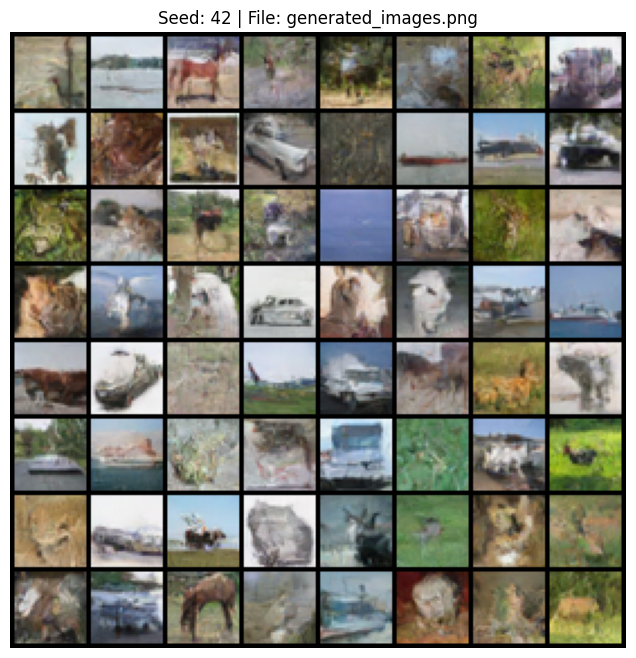

In [7]:
import argparse
import os
import torch
import torchvision.utils as vutils
from multiprocessing import freeze_support
import random
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

class DiffInferenceConfig:
    # 路径与文件
    model_path = '/kaggle/input/ml-course4-diffusion/pytorch/default/1/best_diffusion_model.pth'    # 训练好的模型路径
    output_dir = './output_diff'                 # 输出文件夹
    output_name = 'generated_images.png'         # 输出文件名
    
    # 生成参数
    num_images = 64                              # 生成数量
    num_timesteps = 1000                         # 扩散步数 (默认，会被checkpoint覆盖)
    beta_start = 0.0001
    beta_end = 0.02
    
    # 系统参数
    seed = 42
    no_cuda = False

args = DiffInferenceConfig()

torch.manual_seed(args.seed)

# Create output directory if it doesn't exist
if not os.path.exists(args.output_dir):
    os.makedirs(args.output_dir)

# Initialize the SimpleUNet model
model = SimpleUNet().to(device)

# Load the trained model
if os.path.isfile(args.model_path):
    print(f"Loading model from {args.model_path}...")
    checkpoint = torch.load(args.model_path, map_location=device, weights_only=False)
    
    # Load model state dict
    model.load_state_dict(checkpoint['model'])
    
    if 'args' in checkpoint:
        if hasattr(checkpoint['args'], 'num_timesteps'):
            args.num_timesteps = checkpoint['args'].num_timesteps
        if hasattr(checkpoint['args'], 'beta_start'):
            args.beta_start = checkpoint['args'].beta_start
        if hasattr(checkpoint['args'], 'beta_end'):
            args.beta_end = checkpoint['args'].beta_end
    
    print(f"Model loaded successfully! Using {args.num_timesteps} timesteps.")
else:
    print(f"Error: No model found at {args.model_path}")
    exit(1)

# Set the model to evaluation mode
model.eval()

# Define noise schedule
betas = torch.linspace(args.beta_start, args.beta_end, args.num_timesteps, device=device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = torch.cat([torch.ones(1, device=device), alphas_cumprod[:-1]])
alpha_cumprod_next = torch.cat([alphas_cumprod[1:], torch.ones(1, device=device)])

# Precompute required values for denoising
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
log_one_minus_alphas_cumprod = torch.log(1.0 - alphas_cumprod)
sqrt_recip_alphas_cumprod = torch.sqrt(1.0 / alphas_cumprod)
sqrt_recipm1_alphas_cumprod = torch.sqrt(1.0 / alphas_cumprod - 1)

# Calculate posterior variance
algorithm_type = "ddpm"
if algorithm_type == "ddpm":
    posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
else:
    posterior_variance = betas
posterior_log_variance_clipped = torch.log(posterior_variance.clamp(min=1e-20))
posterior_mean_coef1 = betas * torch.sqrt(alphas_cumprod_prev) / (1.0 - alphas_cumprod)
posterior_mean_coef2 = (1.0 - alphas_cumprod_prev) * torch.sqrt(alphas) / (1.0 - alphas_cumprod)

def p_sample_loop(shape):
    print(f"Generating {shape[0]} images from noise...")
    
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
    sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
    
    with torch.no_grad():
        x = torch.randn(shape, device=device)
        
        for i in tqdm(reversed(range(0, args.num_timesteps)), desc="Denoising", total=args.num_timesteps):
            t = torch.full((shape[0],), i, device=device, dtype=torch.long)
            
            noise_pred = model(x, t)
            
            beta_t = betas[i]
            sqrt_one_minus_alpha_cumprod_t = sqrt_one_minus_alphas_cumprod[i]
            sqrt_recip_alpha_t = sqrt_recip_alphas[i]
            
            mean = sqrt_recip_alpha_t * (x - (beta_t / sqrt_one_minus_alpha_cumprod_t) * noise_pred)
            
            # 加入噪声 (除了最后一步 t=0)
            if i > 0:
                noise = torch.randn_like(x)
                sigma = torch.sqrt(beta_t) # Option 1: sigma = sqrt(beta)
                x = mean + sigma * noise
            else:
                x = mean # 最后一步不加噪声
                
    return x

def p_sample(model, x, t):
    """Sample x_{t-1} from x_t and model"""
    # Get current timestep values
    sqrt_recip_alphas_cumprod_t = sqrt_recip_alphas_cumprod[t][:, None, None, None]
    sqrt_recipm1_alphas_cumprod_t = sqrt_recipm1_alphas_cumprod[t][:, None, None, None]
    posterior_variance_t = posterior_variance[t][:, None, None, None]
    posterior_mean_coef1_t = posterior_mean_coef1[t][:, None, None, None]
    posterior_mean_coef2_t = posterior_mean_coef2[t][:, None, None, None]
    
    # Predict noise
    noise_pred = model(x, t)
    
    # Calculate mean and variance for the reverse process
    mean = sqrt_recip_alphas_cumprod_t * (x - sqrt_recipm1_alphas_cumprod_t * noise_pred)
    
    # If we're at t=0, return the mean (no more noise)
    if t[0] == 0:
        return mean
    else:
        # Add noise to the mean according to the posterior variance
        noise = torch.randn_like(x)
        variance = torch.exp(0.5 * posterior_log_variance_clipped[t])[:, None, None, None]
        return mean + variance * noise

# Generate images

generated_images_list = []
for i in tqdm(range(0, args.num_images, 32), desc="Generating"):
    current_batch_size = min(32, args.num_images - i)
    noise_shape = (current_batch_size, 3, 32, 32)
    generated_images_batch = p_sample_loop(noise_shape)
    generated_images_list.append(generated_images_batch)
generated_images = torch.cat(generated_images_list, dim=0)

print("Calculating FID...")
random.seed(args.seed)
real_indices = random.sample(range(len(test_dataset)), args.num_images)
real_images = torch.stack([test_dataset[i][0] for i in real_indices]).to(device)
    
# Calculate FID score
fid_score = fid_calculator(real_images, generated_images, batch_size=32)
print(f"FID Score: {fid_score:.4f}")

print("Calculating Inception Score...")
is_calculator = InceptionScoreCalculator(device=device)
inception_score, std_inception_score = is_calculator.compute_inception_score(
    generated_images)
print(f"Inception Score: {inception_score:.4f} ± {std_inception_score:.4f}")

generated_images_save = generated_images[:64]
output_path = os.path.join(args.output_dir, args.output_name)
vutils.save_image(generated_images_save, output_path, normalize=True, nrow=8)

print(f"Generated {args.num_images} images and saved to {output_path}")

print("\nDisplaying generated results:")
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title(f"Seed: {args.seed} | File: {args.output_name}")
grid_img = vutils.make_grid(generated_images_save.cpu()[:64], padding=2, normalize=True, nrow=8)
plt.imshow(np.transpose(grid_img, (1, 2, 0)))
plt.show()


【Diffusion】还可以通过下面的代码查看1000步的去噪过程是如何一步步得到生成图像的

In [ ]:
import os
import torch
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

# --- 1. 可视化配置参数 ---
class VizConfig:
    # 路径配置
    model_path = '/kaggle/input/ml-course4-diffusion/pytorch/default/1/best_diffusion_model.pth'
    output_dir = './output_diff_steps'  # 🆕 可视化结果保存路径
    
    # 生成参数
    num_images = 64              # 仅需生成 64 张
    
    # 扩散模型参数 (必须与训练一致)
    num_timesteps = 1000
    beta_start = 0.0001
    beta_end = 0.02
    
    # 系统参数
    seed = 42
    no_cuda = False

args = VizConfig()

def visualize_diffusion_process():
    # 1. 环境设置
    global device
    if 'device' not in globals():
        device = torch.device("cuda" if not args.no_cuda and torch.cuda.is_available() else "cpu")
    print(f"Running visualization on: {device}")
    
    torch.manual_seed(args.seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(args.seed)
        
    if not os.path.exists(args.output_dir):
        os.makedirs(args.output_dir)
        print(f"Created output directory: {args.output_dir}")

    # 2. 准备参数
    betas = torch.linspace(args.beta_start, args.beta_end, args.num_timesteps, device=device)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
    sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

    # 3. 加载模型
    try:
        model = SimpleUNet().to(device)
        if os.path.isfile(args.model_path):
            print(f"Loading model from {args.model_path}...")
            checkpoint = torch.load(args.model_path, map_location=device, weights_only=False)
            model.load_state_dict(checkpoint['model'])
            print("Model loaded successfully!")
        else:
            print(f"Model not found at {args.model_path}")
            return
    except Exception as e:
        print(f"Error: {e}")
        return

    model.eval()

    # --- 4. 带可视化保存的采样函数 ---
    print(f"Starting visualization process (Total Steps: {args.num_timesteps})...")
    
    with torch.no_grad():
        # 1. 从纯高斯噪声开始 x_T (Step 1000)
        x = torch.randn(args.num_images, 3, 32, 32, device=device)
        
        # 保存初始噪声状态 (Step 1000)
        # 严格来说这还没开始去噪，但为了完整性可以存一下，或者按你的要求只存整百步
        # vutils.save_image(x, f"{args.output_dir}/diffusion_step_noise.png", normalize=True, nrow=8)
        
        # 2. 倒序去噪 T-1 -> 0
        for i in tqdm(reversed(range(0, args.num_timesteps)), desc="Denoising Progress", total=args.num_timesteps):
            t = torch.full((args.num_images,), i, device=device, dtype=torch.long)
            
            # 预测噪声
            noise_pred = model(x, t)
            
            # 提取系数
            beta_t = betas[i]
            sqrt_one_minus_alpha_cumprod_t = sqrt_one_minus_alphas_cumprod[i]
            sqrt_recip_alpha_t = sqrt_recip_alphas[i]
            
            # 计算均值 (x_{t-1})
            mean = sqrt_recip_alpha_t * (x - (beta_t / sqrt_one_minus_alpha_cumprod_t) * noise_pred)
            
            if i > 0:
                noise = torch.randn_like(x)
                sigma = torch.sqrt(beta_t)
                x = mean + sigma * noise
            else:
                x = mean
            
            # --- 🆕 可视化保存逻辑 ---
            # 每 100 步保存一次，或者最后一步保存
            if i % 100 == 0 or i == 0:
                save_path = os.path.join(args.output_dir, f'diffusion_step_{i}.png')
                vutils.save_image(x, save_path, normalize=True, nrow=8)
                # 仅打印关键节点日志，避免刷屏
                if i % 200 == 0 or i == 0:
                    print(f"   Snapshot saved: Step {i}")

    print(f"Visualization completed! Check images in {args.output_dir}")
    
    # --- 5. 展示结果 (展示首尾) ---
    steps_to_show = [500, 300, 100, 0]
    
    print(f"\n Displaying steps: {steps_to_show}")
    
    # 创建 2行 x 3列 的画布
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    axs = axs.flatten()
    
    for idx, step in enumerate(steps_to_show):
        img_path = os.path.join(args.output_dir, f'diffusion_step_{step}.png')
        if os.path.exists(img_path):
            img = plt.imread(img_path)
            axs[idx].imshow(img)
            axs[idx].set_title(f"Step {step}")
            axs[idx].axis("off")
        else:
            print(f"Warning: Image for step {step} not found.")
            axs[idx].axis("off")
            
    plt.tight_layout()
    plt.show()

visualize_diffusion_process()